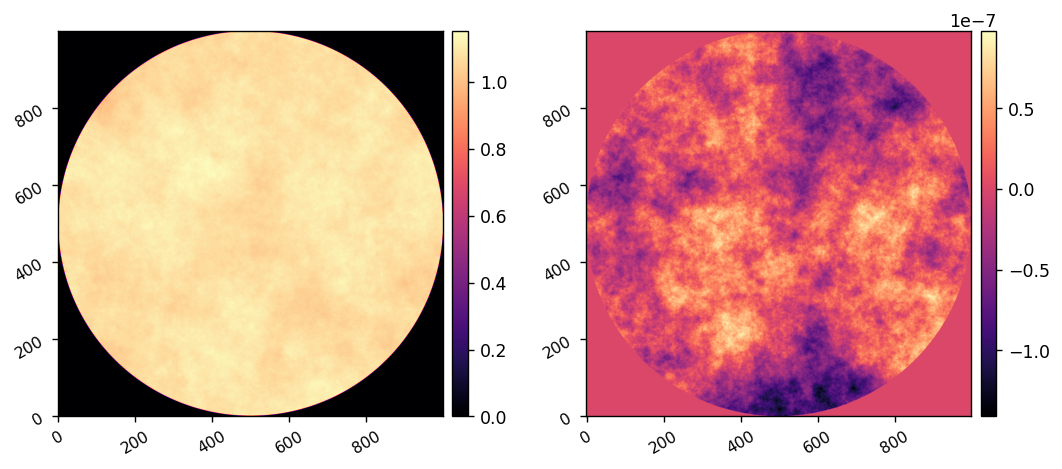

In [24]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import iefc
import scoob_llowfsc.scoob_model as scoobm

# import poppy
# import logging, sys
# poppy_log = logging.getLogger('poppy')
# poppy_log.setLevel('DEBUG')
# logging.basicConfig(stream=sys.stdout, level=logging.INFO)
# poppy_log.disabled = True

wfe_amp = utils.load_fits('example_wfe_amp.fits')
wfe_opd = utils.load_fits('example_wfe_opd.fits')
imshow2(wfe_amp, wfe_opd)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


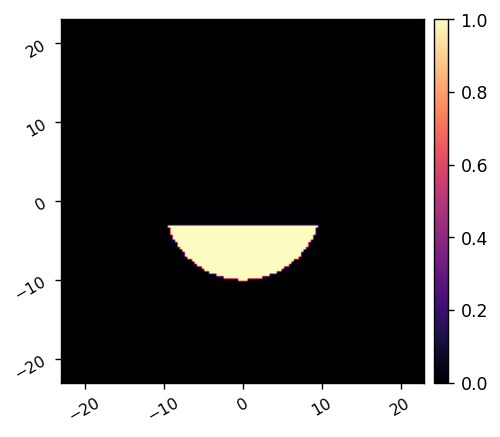

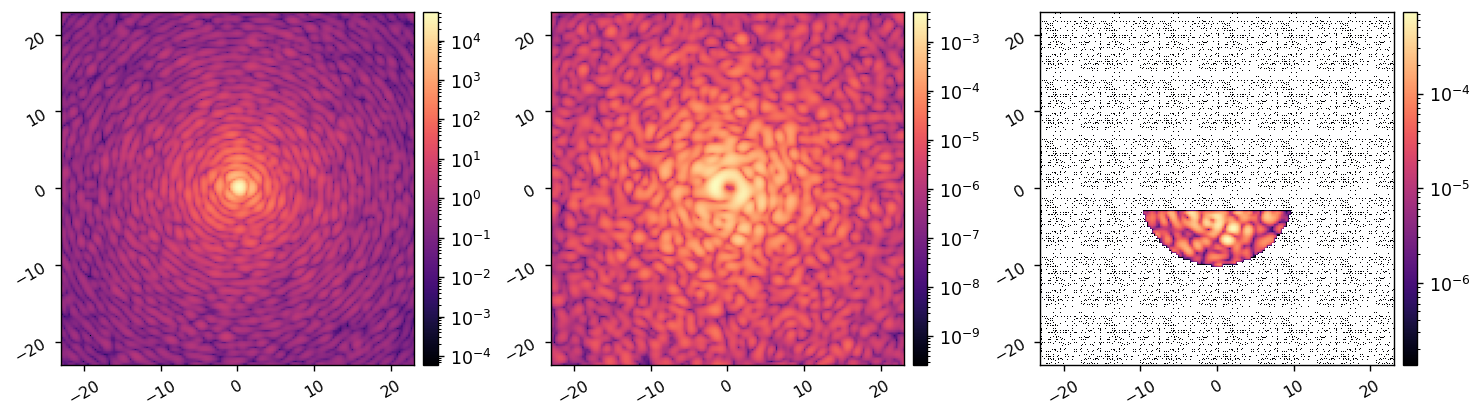

In [25]:
reload(scoobm)
reload(utils)

M = scoobm.single()
M.AMP = wfe_amp
M.OPD = wfe_opd 

iwa = 3
owa = 10
control_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)
imshow1(control_mask, pxscl=M.camsci_pxscl_lamD)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
coro_im0 = M.snap_camsci()

imshow3(
    ref_psf, coro_im0, coro_im0*control_mask,
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
)





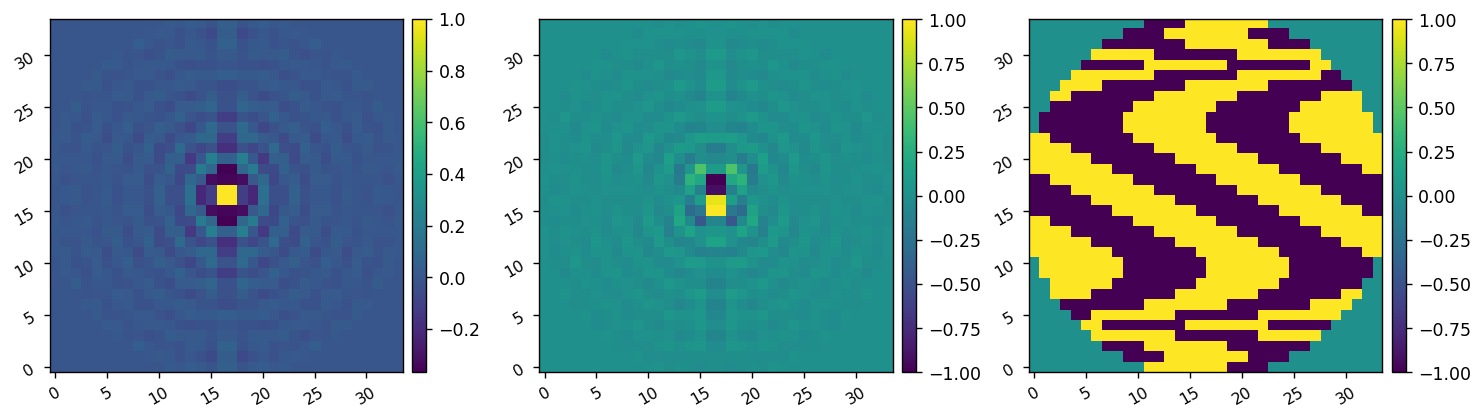

In [26]:
reload(utils)
fourier_probes = utils.create_fourier_probes(
    M.dm_mask, 
    M.ncamsci, M.camsci_pxscl_lamDc, 
    iwa-1, owa+2, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
)

calib_modes = utils.create_hadamard_modes(M.dm_mask)

imshow3(fourier_probes[0], fourier_probes[1], calib_modes[8], cmap1='viridis', cmap2='viridis', cmap3='viridis')

In [ ]:
reload(iefc)
M.reset_dm()

probe_amp = 2e-9
calib_amp = 2e-9

response_matrix, response_cube = iefc.calibrate(
    M, 
    control_mask, 
    probe_amp, fourier_probes, 
    calib_amp, calib_modes, 
)

Calibrating iEFC...
	Calibrated mode 1/1024 in 0.275s
	Calibrated mode 2/1024 in 0.550s
	Calibrated mode 3/1024 in 0.826s
	Calibrated mode 4/1024 in 1.100s
	Calibrated mode 5/1024 in 1.375s
	Calibrated mode 6/1024 in 1.650s
	Calibrated mode 7/1024 in 1.925s
	Calibrated mode 8/1024 in 2.200s
	Calibrated mode 9/1024 in 2.475s
	Calibrated mode 10/1024 in 2.749s
	Calibrated mode 11/1024 in 3.025s
	Calibrated mode 12/1024 in 3.300s
	Calibrated mode 13/1024 in 3.575s
	Calibrated mode 14/1024 in 3.851s
	Calibrated mode 15/1024 in 4.125s
	Calibrated mode 16/1024 in 4.400s
	Calibrated mode 17/1024 in 4.675s
	Calibrated mode 18/1024 in 4.950s
	Calibrated mode 19/1024 in 5.225s
	Calibrated mode 20/1024 in 5.500s
	Calibrated mode 21/1024 in 5.775s
	Calibrated mode 22/1024 in 6.050s
	Calibrated mode 23/1024 in 6.325s
	Calibrated mode 24/1024 in 6.601s
	Calibrated mode 25/1024 in 6.876s
	Calibrated mode 26/1024 in 7.151s
	Calibrated mode 27/1024 in 7.427s
	Calibrated mode 28/1024 in 7.702s
	Calibrat

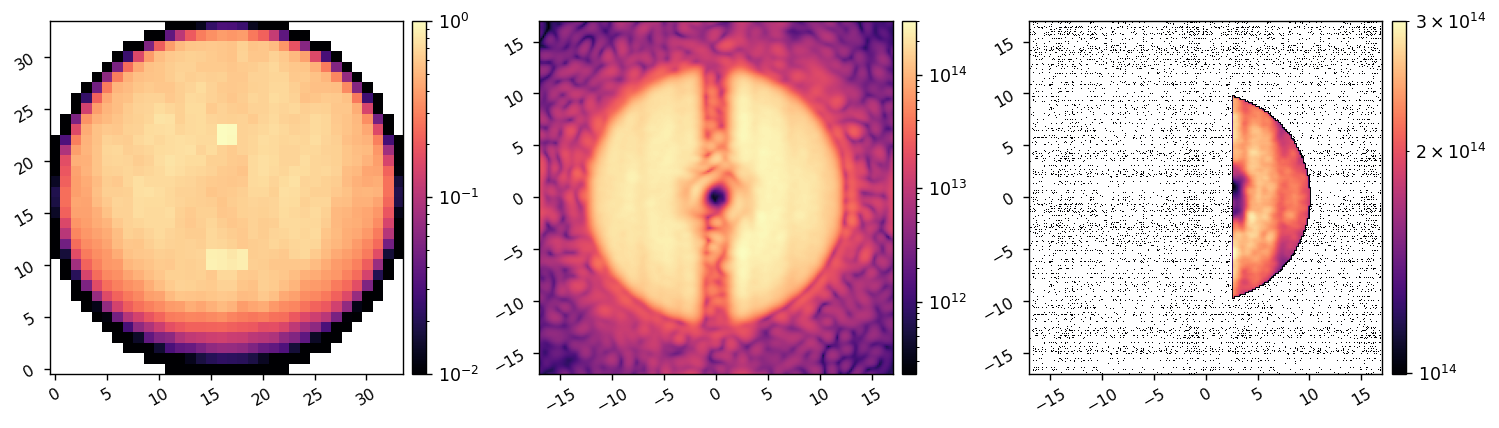

In [48]:
rms_responses = xp.sqrt(xp.mean(xp.square(response_matrix.dot(calib_modes)), axis=0)).reshape(model.Nact, model.Nact)
rms_responses /= xp.max(rms_responses)
fp_response = xp.sum(abs(response_cube), axis=(0,1)).reshape(model.npsf,model.npsf)
imshow3(rms_responses, fp_response, control_mask*fp_response, lognorm=True, vmin1=1e-2, 
        pxscl2=model.psf_pixelscale_lamD, pxscl3=model.psf_pixelscale_lamD)

In [40]:
model.scc_mode

False

In [41]:
model.reset_dm()

dm_commands = xp.array([model.get_dm()])
images = xp.array([im0])

Running iEFC...
	Closed-loop iteration 16 / 18


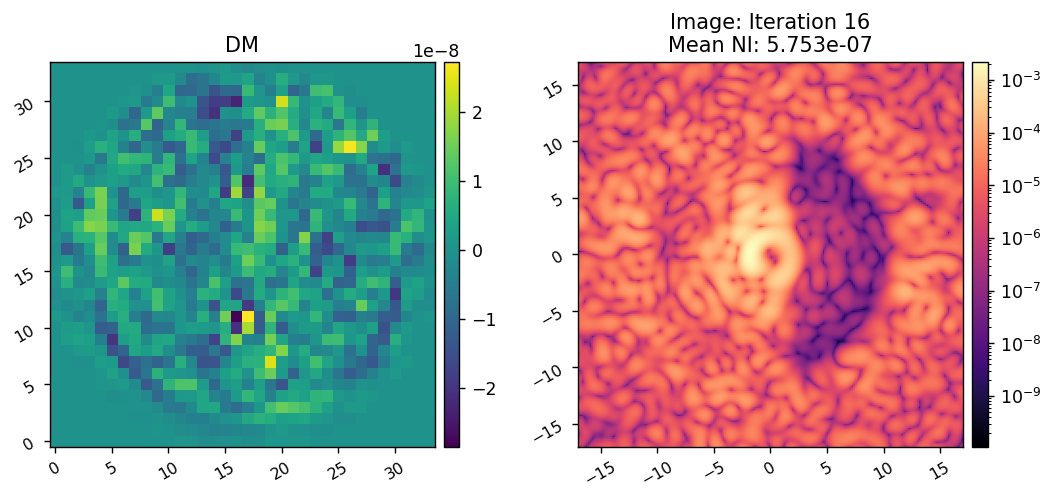

	Closed-loop iteration 17 / 18


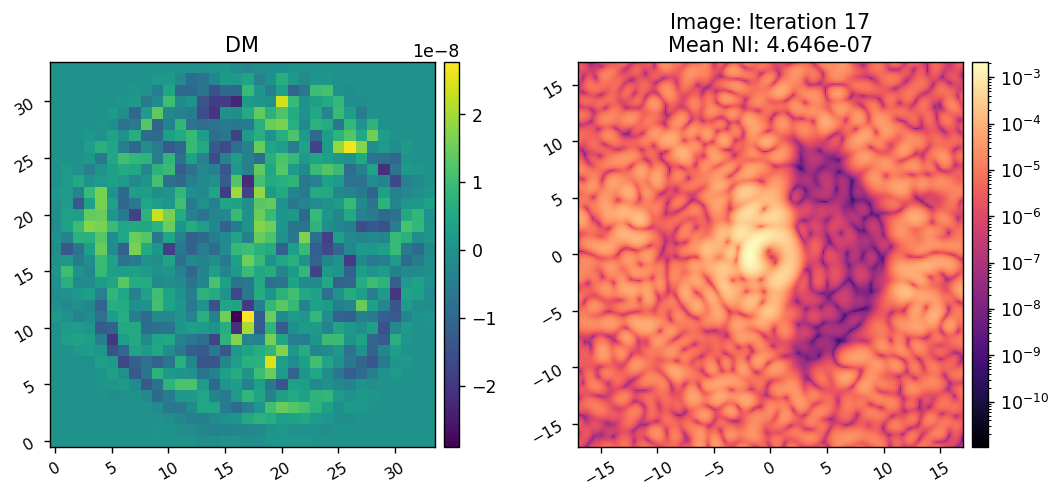

	Closed-loop iteration 18 / 18


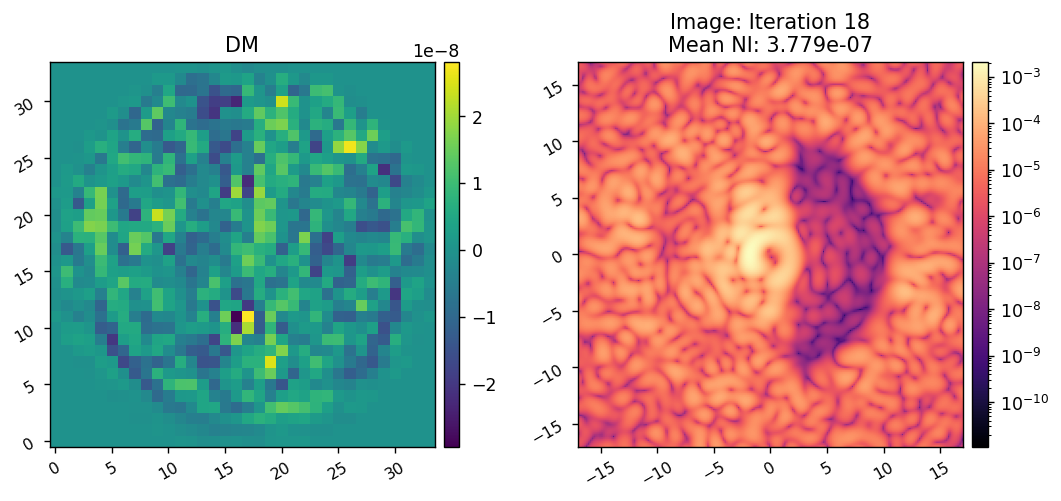

In [47]:
reload(lina.iefc)
reload(lina.utils)

probe_amp = 5e-9
probe_amp = 2.5e-9
probe_amp = 1e-9
# probe_amp = 1e-9/10

reg_cond = -2
reg_cond = -3
# reg_cond = -5

control_matrix = lina.utils.beta_reg(response_matrix, beta=reg_cond)

images, dm_commands = lina.iefc.run(model, 
                              control_matrix,
                              probe_modes, 
                              probe_amp, 
                              calib_modes,
                              control_mask, 
                              num_iterations=3, 
                              loop_gain=0.25, 
                              leakage=0.0,
                              plot_all=True,
                              old_images=images, 
                              old_dm_commands=dm_commands
                             )